In [66]:
# import packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# level 1

My dataset is from IPUMS-US (https://usa.ipums.org/usa-action/data_requests/download). This dataset is a consensus data with variables about immigration identities (eg yrsusa1, race, etc) and health insurance status. By choosing this dataset, I want to explore the relationship between immigration identities and insurance status and try to classify which groups may have less access to the insurance (classificaiton problem). In this case, the result might reveal some insights for future insurance policies. My research question is, how does the years staying in US associate with status of obtaining insurance from employers and which groups have lower access to the insurance?

In [4]:
# Import Data
file_path = '/Users/bojia/Desktop/usa_00001.dta.gz'
df = pd.read_stata(file_path)

In [5]:
# Display the data
df.head()

,year,multyear,sex,age,birthyr,race,raced,yrimmig,yrsusa1,language,...,hinsemp,hinspur,hinstri,hcovpub,hinscaid,hinscare,hinsva,hinsihs,pwstate2,pwcounty
0,2022,2018,female,19,1999,white,white,n/a,n/a or less than one year,english,...,has insurance through employer/union,no insurance purchased directly,no insurance through tricare,without public health insurance coverage,no insurance through medicaid,no,no insurance through va,no insurance through indian health service,n/a,0
1,2022,2018,female,18,2000,black/african american,black/african american,n/a,n/a or less than one year,english,...,has insurance through employer/union,no insurance purchased directly,no insurance through tricare,without public health insurance coverage,no insurance through medicaid,no,no insurance through va,no insurance through indian health service,n/a,0
2,2022,2018,male,53,1965,white,white,n/a,n/a or less than one year,spanish,...,no insurance through employer/union,no insurance purchased directly,no insurance through tricare,without public health insurance coverage,no insurance through medicaid,no,no insurance through va,no insurance through indian health service,n/a,0
3,2022,2018,male,28,1990,white,white,n/a,n/a or less than one year,english,...,no insurance through employer/union,no insurance purchased directly,no insurance through tricare,without public health insurance coverage,no insurance through medicaid,no,no insurance through va,no insurance through indian health service,n/a,0
4,2022,2018,female,25,1993,white,white,n/a,n/a or less than one year,english,...,has insurance through employer/union,no insurance purchased directly,no insurance through tricare,without public health insurance coverage,no insurance through medicaid,no,no insurance through va,no insurance through indian health service,n/a,0


In [6]:
#see column names
df.columns

Index(['year', 'multyear', 'sex', 'age', 'birthyr', 'race', 'raced', 'yrimmig',
       'yrsusa1', 'language', 'languaged', 'racamind', 'racasian', 'racblk',
       'racpacis', 'racwht', 'racother', 'racnum', 'hcovany', 'hcovpriv',
       'hinsemp', 'hinspur', 'hinstri', 'hcovpub', 'hinscaid', 'hinscare',
       'hinsva', 'hinsihs', 'pwstate2', 'pwcounty'],
      dtype='object')

In [70]:
# Data Cleaning

# Select columns that will be examined
research_columns = ['yrsusa1','hinsemp'] 
df_filtered = df[research_columns]
#rename columns
df_filtered = df_filtered.rename(columns={'yrsusa1': 'yearusa', 'hinsemp': 'insurance'})

# Display the filtered dataset
df_filtered.head()

,yearusa,insurance
0,n/a or less than one year,has insurance through employer/union
1,n/a or less than one year,has insurance through employer/union
2,n/a or less than one year,no insurance through employer/union
3,n/a or less than one year,no insurance through employer/union
4,n/a or less than one year,has insurance through employer/union


In [71]:
# see the data details
df_filtered.describe()

,yearusa,insurance
count,15721123,15721123
unique,89,2
top,n/a or less than one year,has insurance through employer/union
freq,13655244,8583273


In [72]:
# remove na & stay in the US less than one year
df_filtered['yearusa']
# Count the frequency of each word
df_filtered['yearusa'].value_counts()
# Drop rows with NA values
df_filtered = df_filtered[df_filtered['yearusa'] != 'n/a or less than one year']
df_filtered['yearusa'].value_counts()

1                            57243
3                            56404
20                           54924
4                            53275
2                            52824
                             ...  
82                             275
78                             205
81                             182
88                             140
n/a or less than one year        0
Name: yearusa, Length: 89, dtype: int64

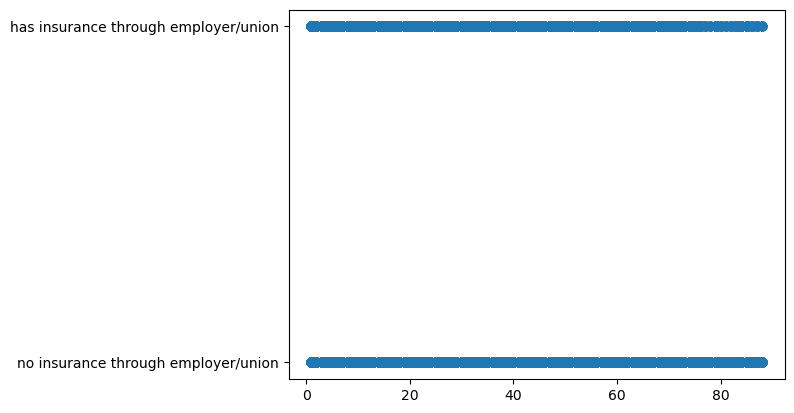

In [73]:
# get a quick look of the data pattern
plt.scatter(df_filtered['yearusa'],df_filtered['insurance'])

# Level 2

As my depedent variable is binary (obtaining insurance from employers or not), and my research question is a classification problm, so in this case, I think logistic regression model will suit for my problem.

In [87]:
# creaet arrays for logistic regressions
yearusa = df_filtered['yearusa'].values.reshape(-1, 1) #turn to 2-d array
insurance=df_filtered['insurance'].values

In [88]:
#Split data into separate training and test set 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(yearusa, insurance, test_size = 0.2, random_state = 0)
#splite the data

In [89]:
#classification model
from sklearn.linear_model import LogisticRegression
 
lr = LogisticRegression()
lr.fit(X_train, y_train)
#fit the model to thd data
lr.predict(X_test)
lr.score(X_test, y_test)

0.5036473560903828

In [91]:
#get coefficients
print(lr.coef_,lr.intercept_)

[[0.00396794]] [-0.02090544]


The coefficients is 0,003976, indicating a very very weak, positive relationship between years in the US and obtaining insurance from employers. The logistic regression score is 0.5036, indicating that the accuracy is around 50.36%, suggesting a not strong relationship between 'yearusa' (years staying in the US) and 'insurance' (having insurance from employers or not). This also suggests that maybe we should take other factors like language skills into consideration to explain the relationship between immigration status and insurance status.

reference links:
https://www.w3schools.com/python/python_ml_logistic_regression.asp
https://www.datacamp.com/tutorial/understanding-logistic-regression-python
https://towardsdatascience.com/building-a-logistic-regression-in-python-step-by-step-becd4d56c9c8
https://www.geeksforgeeks.org/ml-logistic-regression-using-python/

# Level 3

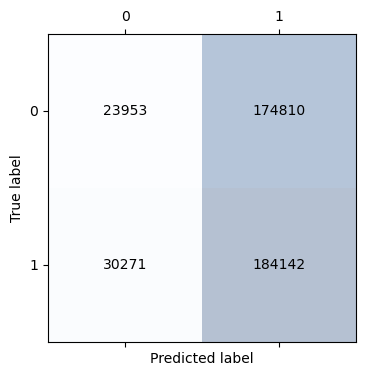

In [95]:
from sklearn.metrics import auc, confusion_matrix,  f1_score, precision_score, recall_score, roc_curve
#import packages

y_pred = lr.predict(X_test)
confmat = confusion_matrix(y_true=y_test, y_pred=y_pred) #create a confusion matrix

fig, ax = plt.subplots(figsize=(4,4)) #plot the confusion matrix
ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(x=j, y=i, s=confmat[i, j], va='center', ha='center')

plt.xlabel('Predicted label')
plt.ylabel('True label')

plt.show()

In [96]:
#calculate accuracy score and precision
true_negatives = 23953
false_positives = 174810
false_negatives = 30271
true_positives = 184142

# calculate total number
total= true_negatives + false_positives + false_negatives + true_positives
accuracy = (true_positives +true_negatives) /total #calculate accuracy
precision=true_positives/(true_positives +false_positives)#calculate precision

print(accuracy, precision)

0.5036473560903828 0.5129989525061847


I used a confusion matrix to valuate my logistic regression model. According to the results, the true negatives is 23953; the false positives is 174810; the false negatives is 30,271; and the true positives is 184,142. Then, an accuracy score of 0.5036 indicates that this model can accurately classify about 50.3% results, and a precision score of 0.5129989 indicates that for about 51.3% of results classified positive by this model is truly positive. 

reference links:
https://nthu-datalab.github.io/ml/labs/06_Logistic-Regression_Metrics/06_Logistic-Regression_Metrics.html